### Imports and Libraries

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate

### EDA

In [90]:
df = pd.read_csv("../data/processed/spells_working.csv")
df.head()

,name,description
0,Aberto,Opens locked doors
1,Accio,Summons objects
2,Aguamenti,Summons water
3,Alohomora,Unlocks objects
4,Anapneo,Clears someone's airway


In [91]:
df.shape

(102, 2)

In [92]:
df.columns

Index(['name', 'description'], dtype='object')

In [93]:
df.isnull().sum()

name           0
description    0
dtype: int64

In [94]:
df["description_clean"] = df["description"].str.lower().str.strip()
df.head()

,name,description,description_clean
0,Aberto,Opens locked doors,opens locked doors
1,Accio,Summons objects,summons objects
2,Aguamenti,Summons water,summons water
3,Alohomora,Unlocks objects,unlocks objects
4,Anapneo,Clears someone's airway,clears someone's airway


In [95]:
df.duplicated().sum()

0

In [96]:
df = df.drop_duplicates()

In [97]:
df["description_length"] = df["description_clean"].apply(len)
df["description_length"].describe()

count    102.000000
mean      45.235294
std       32.652438
min       13.000000
25%       28.000000
50%       34.000000
75%       50.000000
max      171.000000
Name: description_length, dtype: float64

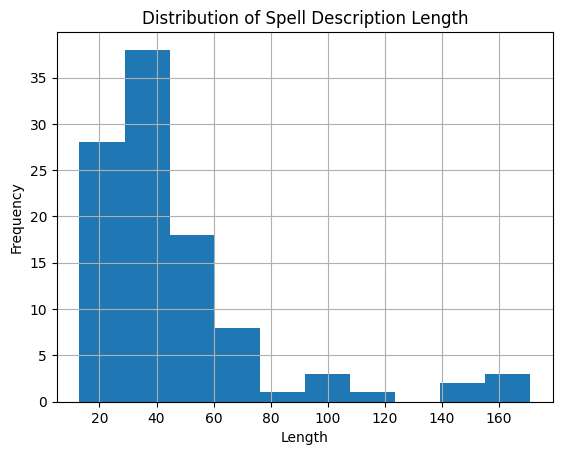

In [98]:
df["description_length"].hist()
plt.title("Distribution of Spell Description Length")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

### Labels

In [99]:
dark_spells = [
    "Avada Kedavra",
    "Crucio",
    "Imperio",
    "Morsmordre",
    "Unbreakable Vow",
    "Sectumsempra",
    "Fiendfyre Curse",
    "Maledictus Curse",
    "Tenebris Hex",
    "Dominium Curse",
    "Tormenta Curse",
    "Infernum Spell",
    "Debilitus Hex",
    "Obedientia Curse",
    "Doloris Charm",
    "Vitalis Drain",
    "Mortifer Spell",
    "Dolohov's Curse",
    "Killing Curse",
    "Blood Boiling Curse",
    "Entrail-Expelling Curse",
    "Cruciatus Curse",
    "Imperius Curse",
    "Dark Mark"
]

df["label"] = df["name"].apply(
    lambda x: "dark" if x in dark_spells else "non-dark"
)

df["label"].value_counts()
df["label"].value_counts(normalize=True)

df[df["label"] == "dark"][["name", "description_clean"]]

,name,description_clean
8,Avada Kedavra,"also known as the killing curse, the most evil..."
17,Crucio,"one of three unforgivable curses, it causes un..."
29,Fiendfyre Curse,"conjures destructive, enormous enchanted flames"
39,Imperio,"one of the three unforgivable curses, it place..."
47,Morsmordre,conjures and projects lord voldemort's dark mark
68,Sectumsempra,inflicts severe lacerations and haemorrhaging ...
75,Unbreakable Vow,a magically binding contract that results in t...
77,Maledictus Curse,causes unbearable pain to the target
78,Tenebris Hex,kills instantly without warning
79,Dominium Curse,controls the victim’s mind completely


In [100]:
df.to_csv("../data/processed/spells_clean.csv", index=False)

### Vectorization

In [101]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["description_clean"])
y = df["label"]

### Train/Test split

In [102]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

### Train model

In [103]:
model = LinearSVC(class_weight="balanced")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.8095238095238095
              precision    recall  f1-score   support

        dark       0.50      0.25      0.33         4
    non-dark       0.84      0.94      0.89        17

    accuracy                           0.81        21
   macro avg       0.67      0.60      0.61        21
weighted avg       0.78      0.81      0.78        21



### Evaluate model

In [104]:
scores = cross_val_score(model, X, y, cv=5, scoring="f1_macro")

print("F1 Macro Scores:", scores)
print("Average F1 Macro:", scores.mean())

F1 Macro Scores: [0.65945946 0.44736842 0.65714286 0.72222222 0.72222222]
Average F1 Macro: 0.6416830364198786


## Model Evaluation Summary

The model achieves an average macro F1 score of ~0.48 using 5-fold cross-validation.

Performance is limited due to:
- very small dataset (~70 samples)
- class imbalance (few dark spells)
- simple feature representation (TF-IDF on short descriptions)

In some folds, the model fails to predict the minority class, resulting in undefined precision.

This model serves as a baseline. Improvements would require:
- more labeled data
- better labeling strategy
- more advanced models

In [105]:
results = cross_validate(
    model,
    X,
    y,
    cv=5,
    scoring=["precision_macro", "recall_macro", "f1_macro"]
)

print("Recall:", results["test_recall_macro"])
print("F1:", results["test_f1_macro"])

Recall: [0.625      0.5        0.6372549  0.66666667 0.66666667]
F1: [0.65945946 0.44736842 0.65714286 0.72222222 0.72222222]


/Users/ana/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [106]:
joblib.dump(model, "../ml/models/spell_classifier.pkl")
joblib.dump(vectorizer, "../ml/models/tfidf_vectorizer.pkl")

['../ml/models/tfidf_vectorizer.pkl']

In [107]:
model = joblib.load("../ml/models/spell_classifier.pkl")
vectorizer = joblib.load("../ml/models/tfidf_vectorizer.pkl")

user_input = "causes unbearable pain"

X_new = vectorizer.transform([user_input])
prediction = model.predict(X_new)

print(prediction)

['non-dark']
